### **Autor**: David Roca Tauste

---
---
# EJERCICIOS FINALES TEMA 2
---
---

### **EJERCICIO 8: En el ejemplo 2 de la página 17 se ha construido un modelo de regresión lineal que intenta explicar la nota obtenida en un control (target) a partir de las horas dedicadas a estudiarlo (predictora). Se ha calculado el R2 con datos de test dando un valor de 0.97. Responde a estas preguntas:**

### a) Parece tener sentido usar este modelo a la vista del valor del coeficiente de determinación.
Sí, tiene sentido usar este modelo, ya que el coeficiente de determinación (R2 = 0'97) indica que el modelo ha aprendido el 97% de la varianza, es decir, las horas estudiadas explican el 97% de la nota obtenida.

### b) Calcula el SSR usando su fórmula (el SSR que aparce calculado en el ejemplo nosotros lo llamamos SSE).
El SSR, según el PDF, es: 1510.01

### c) Comprueba que se cumple que SST = SSE + SSR (los valores ya los tienes).
SST = 1547.55<br>
SSR = 1510.01

SSE = SST - SSR = 1547.55 - 1510.01 = 37.54

### d) Calcula SSR usando la fórmula SST = SSE + SSR. ¿Coincide con el valor calculado?
El SSR es (pasos):
 - SSR = SST - SSE
 - SSR = 1547.55 - 37.54
 - SSR = 1510.01

El SSR del punto b) coincide con el valor calculado, por lo tanto, es correcto.

---
### **EJERCICIO 9: En el ejemplo 17 (enlace) se calcula el índice de inflación de la varianza usando dataset 'BIM.csv'. Calcula ahora su matriz de correlaciones para el dataset y comprueba si visualmente también se detectan las mismas columnas que pueden causar colinealidad en un modelo de regresión. Muestra el gráfico e indica las columnas correlacionadas.**

In [36]:
import pandas as pd
datos = pd.read_csv('BMI.csv')

from statsmodels.stats.outliers_influence import variance_inflation_factor
datos['Gender'] = datos['Gender'].map({'Male':0, 'Female':1})

X = datos[['Gender', 'Height', 'Weight']]
vif_datos = pd.DataFrame()
vif_datos["feature"] = X.columns
vif_datos["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_datos) # height y weight tienen correlaciones. Si usas los dos tienes colinealidad

  feature        VIF
0  Gender   2.028864
1  Height  11.623103
2  Weight  10.688377


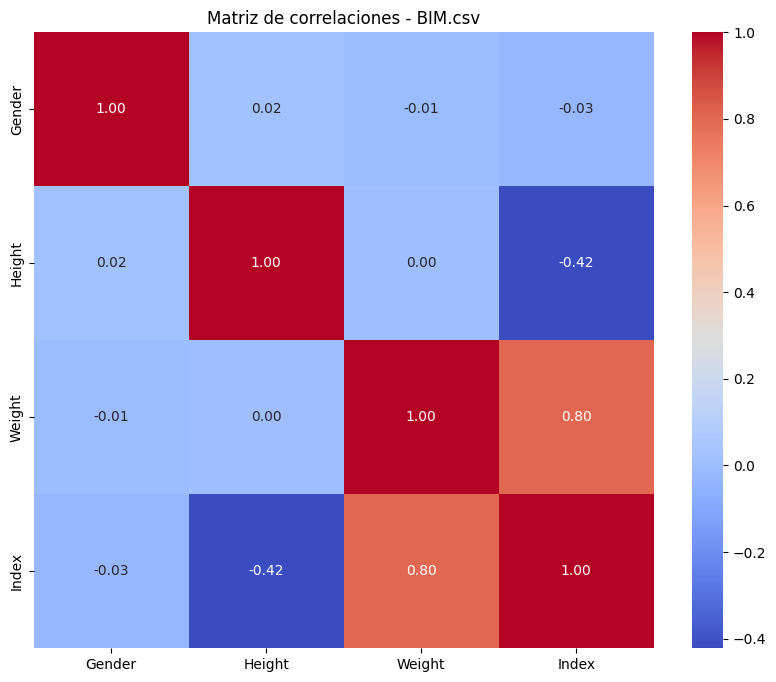

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlaciones
matriz_correlaciones = datos.corr()

# Mostrar heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlaciones, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlaciones - BIM.csv")
plt.show()

Las columnas correlacionadas son:
 - Height con Index
 - Weight con Index

---
### **EJERCICIO 10: En el ejemplo 19 (enlace) se calculan los VIF del ejemplo 18 y se elimina una de las columnas que puede causar colinealidad. Modifica el código para que siga descartando columnas mientras alguna pase el límite aconsejable de VIF. Muestra una captura de su ejecución.**

In [38]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn import preprocessing

df = pd.read_csv('Housing_Modified.csv') # Cargar datos

# Convertir campos binarios a campos booleanos numéricos
lb = preprocessing.LabelBinarizer()
df.driveway = lb.fit_transform(df.driveway)
df.recroom = lb.fit_transform(df.recroom)
df.fullbase = lb.fit_transform(df.fullbase)
df.gashw = lb.fit_transform(df.gashw)
df.airco = lb.fit_transform(df.airco)
df.prefarea = lb.fit_transform(df.prefarea)

# Crea variables dummy para stories
df_stories = pd.get_dummies(df['stories'], prefix='stories', drop_first=True)
df = pd.concat([df, df_stories], axis=1) # Unir variables dummy al dataframe
del df['stories'] # Borrar la original

# Codificar las dummies como numéricas 1 = True, 0=False para hacer cálculos
df['stories_one'] = df['stories_one'].map({True:1, False:0})
df['stories_two'] = df['stories_two'].map({True:1, False:0})
df['stories_three'] = df['stories_three'].map({True:1, False:0})

# Definir la lista de columnas predictoras a través de sus nombres
preds = ['lotsize', 'bedrooms', 'bathrms', 'driveway', 'recroom', 'fullbase', 'gashw',
'airco', 'garagepl', 'prefarea', 'stories_one', 'stories_two', 'stories_three']

limite = 8

while True:
    X = df[preds]
    vif = [variance_inflation_factor(X.values, ix) for ix in range(X.shape[1])]
    max_vif = max(vif)
    
    if max_vif > limite:
        maxloc = vif.index(max_vif)
        print(f"\nVIF: {vif}")
        print(f"Eliminando '{preds[maxloc]}' con valor de VIF: {max_vif}")
        del preds[maxloc]
    else:
        break

print("\n-----")
print('Variables Finales:', preds)


VIF: [np.float64(8.958098087844336), np.float64(18.469878559519948), np.float64(8.984672347290864), np.float64(7.08857854209188), np.float64(1.4770152815033917), np.float64(2.013320236472385), np.float64(1.1034879198994194), np.float64(1.756746206560902), np.float64(1.9826489313438442), np.float64(1.5332946465459893), np.float64(3.965752674786861), np.float64(5.511702408354892), np.float64(1.7700402770614867)]
Eliminando 'bedrooms' con valor de VIF: 18.469878559519948

VIF: [np.float64(8.322234031416658), np.float64(6.627299456397192), np.float64(6.989583876433843), np.float64(1.4770126698058086), np.float64(2.0130376890130894), np.float64(1.103420793610341), np.float64(1.7269337726878173), np.float64(1.9808449808044144), np.float64(1.5324409742947782), np.float64(3.421552997730862), np.float64(3.657882437541497), np.float64(1.5298878733105854)]
Eliminando 'lotsize' con valor de VIF: 8.322234031416658

-----
Variables Finales: ['bathrms', 'driveway', 'recroom', 'fullbase', 'gashw', 'a

---
### **EJERCICIO 11. Ejecuta el ejemplo 21 y el ejemplo 22 aplicado al modelo del ejercicio anterior. Indica qué datos son outliers. Ahora aplica alguno de los algoritmos básicos (o el basado en z-scores o el basado en IQR) y comprueba si detectan los mismos outliers.**

In [39]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing

df = pd.read_csv('Housing_Modified.csv') # Cargar datos

# Convertir campos binarios a campos booleanos numéricos
lb = preprocessing.LabelBinarizer()
df.driveway = lb.fit_transform(df.driveway)
df.recroom = lb.fit_transform(df.recroom)
df.fullbase = lb.fit_transform(df.fullbase)
df.gashw = lb.fit_transform(df.gashw)
df.airco = lb.fit_transform(df.airco)
df.prefarea = lb.fit_transform(df.prefarea)

# Crea variables dummy para stories
df_stories = pd.get_dummies(df['stories'], prefix='stories', drop_first=True)
df = pd.concat([df, df_stories], axis=1) # Unirlas al dataset
del df['stories']

# Codificar las dummies como numéricas 1 = True, 0=False para hacer cálculos
df['stories_one'] = df['stories_one'].map({True:1, False:0})
df['stories_two'] = df['stories_two'].map({True:1, False:0})
df['stories_three'] = df['stories_three'].map({True:1, False:0})

# Definir el problema: target ~ predictoras
predictoras = ['lotsize', 'bathrms','driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'garagepl', 'prefarea', 'stories_one','stories_two','stories_three']
X = df[predictoras]
y = df['price']

# Dividir datos en 80/20 para train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.80, random_state=1)

# Crea y entrena un modelo de mínimos cuadrados ordinario e imprimir resumen
import statsmodels.api as sm
x = X_train
y = y_train
x = sm.add_constant(x)
ols = sm.OLS(y,x).fit()
print(ols.summary())# Resumen estadístico del modelo

# Hacer predicciones sobre el dataset test
y_train_pred = ols.predict(x)
X_test = sm.add_constant(X_test)
y_test_pred = ols.predict(X_test)
print( "Train MAE: ", metrics.mean_absolute_error(y_train, y_train_pred))
print( "Train RMSE: ", np.sqrt(metrics.mean_squared_error(y_train, y_train_pred)))
print( "Test MAE: ", metrics.mean_absolute_error(y_test, y_test_pred))
print( "Test RMSE: ", np.sqrt(metrics.mean_squared_error(y_test, y_test_pred)))

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     75.77
Date:                Thu, 27 Mar 2025   Prob (F-statistic):           2.38e-97
Time:                        12:49:23   Log-Likelihood:                -4810.4
No. Observations:                 436   AIC:                             9647.
Df Residuals:                     423   BIC:                             9700.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2.818e+04   4719.573      5.971

In [40]:
modelo = ols

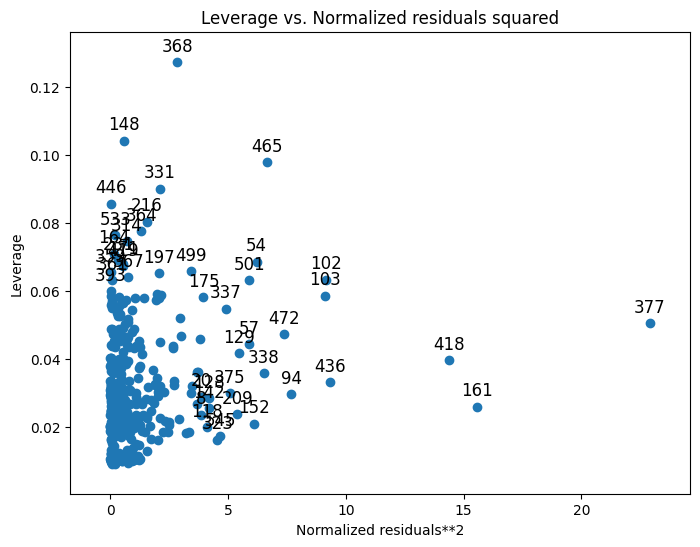

In [41]:
import matplotlib.pyplot as plt
from statsmodels.graphics.regressionplots import plot_leverage_resid2

# Dibujamos los residuos normalizados contra el leverage
fig, ax = plt.subplots(figsize=(8,6))
fig = plot_leverage_resid2(modelo, ax = ax)

273    1.0
40     1.0
397    1.0
339    1.0
411    1.0
      ... 
129    1.0
144    1.0
72     1.0
235    1.0
37     1.0
Name: bonf(p), Length: 436, dtype: float64
Puntos de datos malos (bonf(p) < 0.05):
      student_resid       unadj_p   bonf(p)
161       4.004005  7.358170e-05  0.032082
377       4.970358  9.733744e-07  0.000424


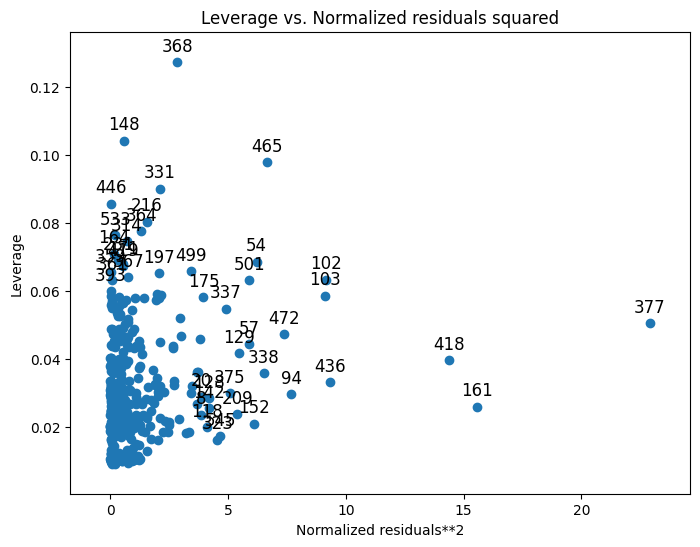

In [42]:
# Encontrar los outliers con el test de outliers de Bonferroni
fig, ax = plt.subplots(figsize=(8,6))
fig = plot_leverage_resid2(ols, ax = ax)
test = modelo.outlier_test()

print(test['bonf(p)'])
print('Puntos de datos malos (bonf(p) < 0.05):\n', test[test['bonf(p)'] < 0.05])

Según el test de outliers de Bonferroni, los siguientes datos son outliers:

Fila | student_resid |      unadj_p |  bonf(p)<br>
161    |    4.004005 | 7.358170e-05 | 0.032082<br>
377    |    4.970358 | 9.733744e-07 | 0.000424<br>

In [43]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar outliers
outliers_iqr = ((df < limite_inferior) | (df > limite_superior)).any(axis=1)
print("Outliers detectados con IQR:\n", df[outliers_iqr])

Outliers detectados con IQR:
         price  lotsize  bedrooms  bathrms  driveway  recroom  fullbase  gashw  \
3     60500.0     6650         3        1         1        1         0      0   
5     66000.0     4160         3        1         1        1         1      0   
7     69000.0     4160         3        1         1        0         0      0   
8     83800.0     4800         3        1         1        1         1      0   
9     88500.0     5500         3        2         1        1         0      0   
..        ...      ...       ...      ...       ...      ...       ...    ...   
537   83000.0     4800         3        1         1        0         0      0   
538   84000.0     6500         3        2         1        0         0      0   
541   91500.0     4800         3        2         1        1         0      0   
543  103000.0     6000         3        2         1        1         0      0   
544  105000.0     6000         3        2         1        1         0      0  

El `test de outliers de Bonferroni` y el `rango intercuartílico (IQR)` no detectan los mismos outliers.

In [44]:
# Outilers que detecta el test de Bonferroni
print(test[test['bonf(p)'] < 0.05].values)

[[4.00400455e+00 7.35817028e-05 3.20816224e-02]
 [4.97035769e+00 9.73374351e-07 4.24391217e-04]]


In [45]:
# Outilers que detecta el rango intercuartílico
print(df[outliers_iqr].values)

[[6.05e+04 6.65e+03 3.00e+00 ... 0.00e+00 0.00e+00 1.00e+00]
 [6.60e+04 4.16e+03 3.00e+00 ... 1.00e+00 0.00e+00 0.00e+00]
 [6.90e+04 4.16e+03 3.00e+00 ... 0.00e+00 1.00e+00 0.00e+00]
 ...
 [9.15e+04 4.80e+03 3.00e+00 ... 0.00e+00 0.00e+00 0.00e+00]
 [1.03e+05 6.00e+03 3.00e+00 ... 0.00e+00 0.00e+00 0.00e+00]
 [1.05e+05 6.00e+03 3.00e+00 ... 0.00e+00 0.00e+00 1.00e+00]]


---
### **EJERCICIO 12: Modifica el ejemplo 28 para calcular también un modelo lineal a los mismos datos y muestra el R2 del modelo lineal y del modelo polinómico con los datos de entrenamiento.**

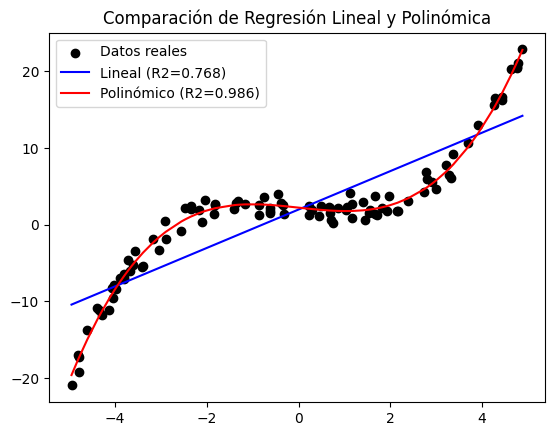

R2 del modelo lineal: 0.7676270971740178
R2 del modelo polinómico: 0.9861039852577537


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Generar datos
n = 100  # Número de puntos de datos
np.random.seed(0)
x = np.sort(10 * np.random.rand(n, 1) - 5, axis=0) 
y = 0.2 * x**3 - 0.5 * x + 2 + np.random.randn(n, 1)

# Modelo de regresión lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(x, y)
y_pred_lineal = modelo_lineal.predict(x)
r2_lineal = r2_score(y, y_pred_lineal)

# Modelo de regresión polinómica
poly = PolynomialFeatures(degree=3, include_bias=False)
x_poli = poly.fit_transform(x)
modelo_poli = LinearRegression()
modelo_poli.fit(x_poli, y)
y_pred_poli = modelo_poli.predict(x_poli)
r2_poli = r2_score(y, y_pred_poli)

# Graficar resultados
plt.scatter(x, y, color="black", label="Datos reales")
plt.plot(x, y_pred_lineal, color="blue", label=f"Lineal (R2={r2_lineal:.3f})")
plt.plot(x, y_pred_poli, color="red", label=f"Polinómico (R2={r2_poli:.3f})")
plt.legend()
plt.title("Comparación de Regresión Lineal y Polinómica")
plt.show()

# R2 de ambos modelos
print(f"R2 del modelo lineal: {r2_lineal}")
print(f"R2 del modelo polinómico: {r2_poli}")

---
### **EJERCICIO 13: Repite el ejercicio 12 anterior, pero ahora divide los datos en train y test usando tu semilla aleatoria personalizada: letras_nombre + letras_ape1 + letras_ape2. Saca los dos modelos y calcula el R2 en los datos de test. ¿Cuál es mejor?**

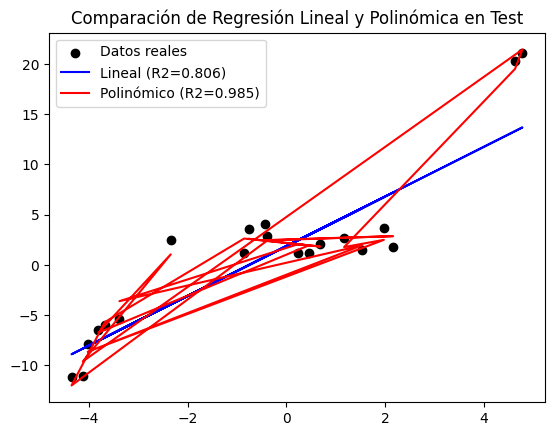

R2 del modelo lineal en test: 0.8057058170065725
R2 del modelo polinómico en test: 0.9848610527631467


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Generar datos
n = 100  # Número de puntos de datos
np.random.seed(0)
x = np.sort(10 * np.random.rand(n, 1) - 5, axis=0) 
y = 0.2 * x**3 - 0.5 * x + 2 + np.random.randn(n, 1)

# Dividir en conjunto de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=546)

# Modelo de regresión lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(x_train, y_train)
y_pred_lineal = modelo_lineal.predict(x_test)
r2_lineal = r2_score(y_test, y_pred_lineal)

# Modelo de regresión polinómica
poly = PolynomialFeatures(degree=3, include_bias=False)
x_train_poli = poly.fit_transform(x_train)
x_test_poli = poly.transform(x_test)

modelo_poli = LinearRegression()
modelo_poli.fit(x_train_poli, y_train)
y_pred_poli = modelo_poli.predict(x_test_poli)
r2_poli = r2_score(y_test, y_pred_poli)

# Graficar resultados
plt.scatter(x_test, y_test, color="black", label="Datos reales")
plt.plot(x_test, y_pred_lineal, color="blue", label=f"Lineal (R2={r2_lineal:.3f})")
plt.plot(x_test, y_pred_poli, color="red", label=f"Polinómico (R2={r2_poli:.3f})")
plt.legend()
plt.title("Comparación de Regresión Lineal y Polinómica en Test")
plt.show()

# R2 de ambos modelos
print(f"R2 del modelo lineal en test: {r2_lineal}")
print(f"R2 del modelo polinómico en test: {r2_poli}")

En cuanto al R2, el modelo polinómico es mejor, con un resultado del 0'984 sobre 1.

---
### **EJERCICIO 14: Tenemos los datos de 'Grade_Set_2.csv', considera otro conjunto de datos de notas de estudiantes.**

    Hours_Studied  Test_Grade
0             0.5          20
1             1.0          21
2             2.0          22
3             3.0          23
4             4.0          25
5             5.0          37
6             6.0          48
7             7.0          56
8             8.0          67
9             9.0          76
10           10.0          90
11           11.0          89
12           12.0          90
Correlation Matrix: 
R Squared:  0.9503677766997879


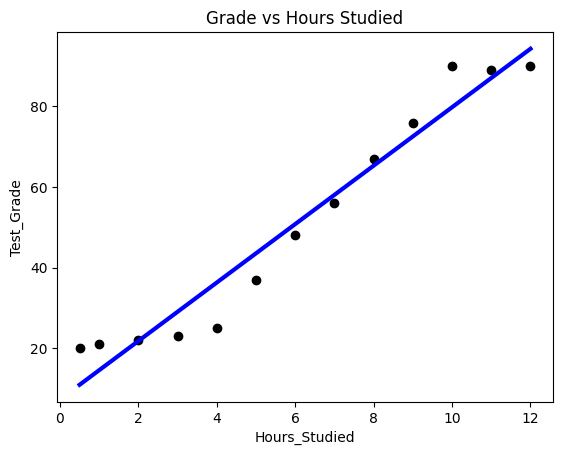

In [48]:
# Carga datos
df = pd.read_csv("Grade_Set_2.csv")
print(df)

# Gráfico
df.plot(
    kind="scatter", x="Hours_Studied", y="Test_Grade", title="Grade vs Hours Studied"
)

# check the correlation between variables
print("Correlation Matrix: ")
df.corr()

# Create linear regression object
lr = LinearRegression()
#x = df.Hours_Studied[:, np.newaxis]  # independent variable
x = df.Hours_Studied.values.reshape(-1, 1)
y = df.Test_Grade  # dependent variable

# Train the model using the training sets
lr.fit(x, y)

# plotting fitted line
plt.scatter(x, y, color="black")
plt.plot(x, lr.predict(x), color="blue", linewidth=3)
plt.title("Grade vs Hours Studied")
plt.ylabel("Test_Grade")
plt.xlabel("Hours_Studied")
print("R Squared: ", r2_score(y, lr.predict(x)))

0.9503677766997879
0.9608726568678714
0.9938323120374665
0.9955000184096712
0.9956204913897359


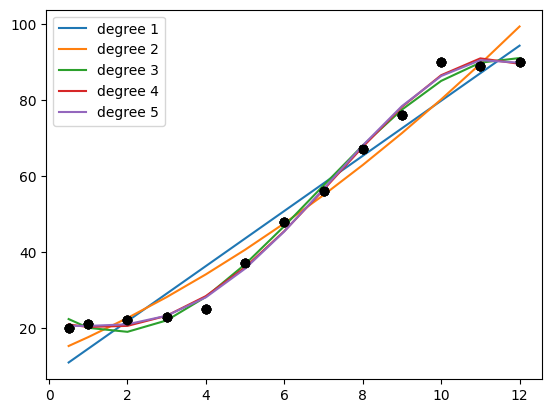

In [49]:
lr = LinearRegression()
x = df.Hours_Studied  # independent variable
y = df.Test_Grade  # dependent variable

for deg in [1, 2, 3, 4, 5]:
    lr.fit(np.vander(x, deg + 1), y)  # función vander() devuelve potencias del vector
    y_lr = lr.predict(np.vander(x, deg + 1))

    plt.plot(x, y_lr, label="degree " + str(deg))
    plt.legend(loc=2)
    print(r2_score(y, y_lr))
    plt.plot(x, y, "ok")

---
### **EJERCICIO 15: Calcula todas las métricas de la matriz de confusión de la figura 71 cuyos datos de ejemplo aparecen en esta tabla.**

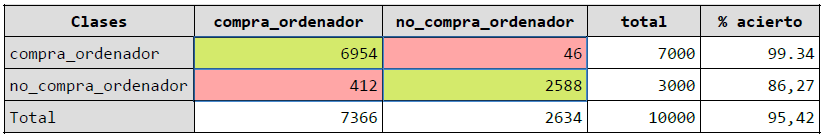

In [50]:
import numpy as np

# Valores de la matriz de confusión
TP = 6954
FP = 46  
FN = 412   
TN = 2588

# Cálculo de métricas
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN) 
specificity = TN / (TN + FP)  
f1_score = 2 * (precision * recall) / (precision + recall)

# Resultados
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensibilidad): {recall:.4f}")
print(f"Specificity (Especificidad): {specificity:.4f}")
print(f"F1-score: {f1_score:.4f}")


Accuracy: 0.9542
Precision: 0.9934
Recall (Sensibilidad): 0.9441
Specificity (Especificidad): 0.9825
F1-score: 0.9681


---
### **EJERCICIO 16: Ejecuta el ejemplo 45 y responde estas cuestiones:**
 - **a) ¿Cuál de los dos modelos es mejor? (justifica tu respuesta)**
 - **b) ¿Es significativa tu respuesta? (¿Está respaldada por alguna prueba más que por tu intuición?)**

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from mlxtend.data import iris_data

# Cargamos datos
x, y = iris_data()

# Creamos dos clasificadores diferentes y los entrenamos con los mismos datos
lr = LogisticRegression(max_iter=150)
dt = DecisionTreeClassifier(max_depth=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
lr.fit(x_train, y_train)
dt.fit(x_train, y_train)
s1 = lr.score(x_test, y_test)
s2 = dt.score(x_test, y_test)

print("Modelo A accuracy: %.2f%%" % (s1 * 100))
print("Modelo B accuracy: %.2f%%" % (s2 * 100))

# Probar si las accuracy son significativas para decantarnos por un modelo
from mlxtend.evaluate import paired_ttest_5x2cv

t, p = paired_ttest_5x2cv(estimator1=lr, estimator2=dt, X=x, y=y)
alfa = 0.05  # Significancia del 5%
print("t-estadístico: %.3f" % t)
print("Significancia alfa ", alfa)
print("p-value: %.3f" % p)

if p > alfa:
    print("Se acepta la hipótesis nula")
else:
    print("Se rechaza la hipótesis nula")

Modelo A accuracy: 97.78%
Modelo B accuracy: 62.22%
t-estadístico: 6.510
Significancia alfa  0.05
p-value: 0.001
Se rechaza la hipótesis nula


**a)** Es mejor el modelo A porque tiene un accuracy del 97'78% frente al 62'22% del modelo B.

**b)** Mi respuesta sí es significativa porque está respaldada por el resto de estadísticas. El t-estadístico tiene un valor de 6'667 y el p-value de 0'001, lo que indica que la diferencia entre los modelos es significativa, ya que el p-value es menor que el nivel de significancia alfa (0'05). Esto quiere decir que podemos rechazar la hipótesis nula y, por lo tanto, saber que la diferencia en precisión no se debe al azar.

---
### **EJERCICIO 17: Utiliza el código del ejemplo 42 para encontrar el mejor hiperparámetro k de un regresor K-NN usado con los datos del ejercicio. Utiliza la métrica que quieras.**

In [52]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Dataset
ruido_sd = 10
X, y, coef = datasets.make_regression(
    n_samples=50,
    n_features=100,
    noise=ruido_sd,
    n_informative=2,
    random_state=42,
    coef=True,
)

# Usar esto para ajustar el parámetro noise para que snr < 5
print("SNR:", np.std(np.dot(X, coef)) / ruido_sd)

# Hiperparámetros
param_grid = {"n_neighbors": np.arange(1, 21)}

# Configurar validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Modelo K-NN
modelo = GridSearchCV(
    KNeighborsRegressor(), param_grid, cv=cv, scoring="neg_mean_squared_error"
)
modelo.fit(X, y)

# Mejor valor de k
y_preds = modelo.predict(X)
print("Mejor valor de k:", modelo.best_params_["n_neighbors"])
print("Error cuadrático medio:", mean_squared_error(y, y_preds))

SNR: 2.6358469446381614
Mejor valor de k: 8
Error cuadrático medio: 524.1283456161004


El mejor hiperparámetro k es 8.

---
### **EJERCICIO 18. Observa el código del ejemplo 47 y responde y realiza las siguientes actividades:**
 - a) Ejecuta el código y toma captura del resultado de la ejecución.
 - b) ¿Qué 5 modelos base tienen la mejor accuracy? Los ordenas de mejor a peor por su nombre.
 - c) Modifica el meta-modelo hard-voting pasándole esos 5 modelos base.
 - d) Modifica el meta-modelo soft-voting pasándole esos 5 modelos base, y además le pasas los pesos modificados de manera que el peso del modelo i-ésimo sea su accuracy dividido por la suma de todas las accuracies.

In [53]:
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from mlxtend.classifier import EnsembleVoteClassifier

np.random.seed(2025)  # Hacerlo reproducible

# Leer datos
df = pd.read_csv("Diabetes.csv")
X = df.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7]]  # variables independientes
y = df["class"]  # variable dependiente

# Dividir datos en train + test y escalar características
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=2025
)

# Entrenar diferentes modelos para clasificar
RL = LogisticRegression(random_state=2025)
RF = RandomForestClassifier(n_estimators=100, random_state=2025)
SVM = SVC(random_state=0, probability=True)
KNC = KNeighborsClassifier()
CART = DecisionTreeClassifier()
ABC = AdaBoostClassifier(n_estimators=100)
BC = BaggingClassifier(n_estimators=100)
GBC = GradientBoostingClassifier(n_estimators=100)

clfs = []
print("==== 5-fold validación cruzada: ====\n")

for clf, label in zip(
    [RL, RF, SVM, KNC, CART, ABC, BC, GBC],
    [
        "Regresión Logística",
        "Random Forest",
        "Máquinas de Soporte Vectorial",
        "KNeighbors",
        "Arbol de Decision",
        "Ada Boost",
        "Bagging",
        "Gradient Boosting",
    ],
):
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
    print(
        "Train CV Accuracy: %0.3f (+/- %0.3f) [%s]"
        % (scores.mean(), scores.std(), label)
    )
    md = clf.fit(X, y)
    clfs.append(md)
    print(
        "Test Accuracy: %0.3f " % (metrics.accuracy_score(clf.predict(X_test), y_test))
    )

# Ensemble Voting
clfs = []
print("\n==== 5-fold CV: ====\n")

ECH = EnsembleVoteClassifier(clfs=[RL, RF, GBC, BC], voting="hard")
ECS = EnsembleVoteClassifier(
    clfs=[RL, RF, GBC, BC], voting="soft", weights=[1, 1, 1, 1]
)

for clf, label in zip([ECH, ECS], ["Ensemble Hard Voting", "Ensemble Soft Voting"]):
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
    print(
        "\nTrain CV Accuracy: %0.3f (+/- %0.3f) [%s]"
        % (scores.mean(), scores.std(), label)
    )
    md = clf.fit(X, y)
    clfs.append(md)
    print(
        "Test Accuracy: %0.2f " % (metrics.accuracy_score(clf.predict(X_test), y_test))
    )

==== 5-fold validación cruzada: ====

Train CV Accuracy: 0.769 (+/- 0.033) [Regresión Logística]
Test Accuracy: 0.779 
Train CV Accuracy: 0.747 (+/- 0.038) [Random Forest]
Test Accuracy: 1.000 
Train CV Accuracy: 0.762 (+/- 0.042) [Máquinas de Soporte Vectorial]
Test Accuracy: 0.818 
Train CV Accuracy: 0.732 (+/- 0.035) [KNeighbors]
Test Accuracy: 0.848 
Train CV Accuracy: 0.691 (+/- 0.035) [Arbol de Decision]
Test Accuracy: 1.000 


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is 

Train CV Accuracy: 0.747 (+/- 0.031) [Ada Boost]


c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Test Accuracy: 0.844 
Train CV Accuracy: 0.762 (+/- 0.034) [Bagging]
Test Accuracy: 1.000 
Train CV Accuracy: 0.762 (+/- 0.034) [Gradient Boosting]
Test Accuracy: 0.939 

==== 5-fold CV: ====


Train CV Accuracy: 0.758 (+/- 0.025) [Ensemble Hard Voting]
Test Accuracy: 0.95 

Train CV Accuracy: 0.769 (+/- 0.022) [Ensemble Soft Voting]
Test Accuracy: 0.97 


- a) Se encuentra en la celda de arriba.

- b) Los 5 modelos con mejor accuracy en test son:
    - Random Forest: 1
    - Arbol de Decision: 1
    - Bagging: 1
    - Gradient Boosting: 0'939
    - KNeighbors: 0'848

- c) Se encuentra en la celda de abajo.

- d) Se encuentra en la celda de abajo.

In [54]:
# Modelos con mejor accuracy en test
mejores_modelos = [
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=2025)),
    ("Arbol de Decision", DecisionTreeClassifier()),
    ("Bagging", BaggingClassifier(n_estimators=100)),
    ("Gradient Boosting", GradientBoostingClassifier(n_estimators=100)),
    ("KNeighbors", KNeighborsClassifier()),
]

# Extraer los modelos
clfs_mejores = [modelo for _, modelo in mejores_modelos]

# Hard Voting con los 5 mejores modelos
ECH = EnsembleVoteClassifier(clfs=clfs_mejores, voting="hard")

# Calcular los pesos para el Soft Voting
accuracies = [1.0, 1.0, 1.0, 0.939, 0.848]
total_acc = sum(accuracies)
pesos = [acc / total_acc for acc in accuracies]

# Soft Voting con los 5 mejores modelos y los pesos ajustados
ECS = EnsembleVoteClassifier(clfs=clfs_mejores, voting="soft", weights=pesos)

# Evaluar meta-modelos
for clf, label in zip([ECH, ECS], ["Ensemble Hard Voting", "Ensemble Soft Voting"]):
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
    print(
        "\nTrain CV Accuracy: %0.3f (+/- %0.3f) [%s]"
        % (scores.mean(), scores.std(), label)
    )
    md = clf.fit(X, y)
    print(
        "Test Accuracy: %0.2f " % (metrics.accuracy_score(clf.predict(X_test), y_test))
    )


Train CV Accuracy: 0.754 (+/- 0.040) [Ensemble Hard Voting]
Test Accuracy: 1.00 

Train CV Accuracy: 0.747 (+/- 0.057) [Ensemble Soft Voting]
Test Accuracy: 1.00 


---
### **EJERCICIO 19. Observa el código del ejemplo 52 y responde y realiza las siguientes actividades:**
 - a) Entrena un modelo lineal con regularización que te permita conocer al menos dos predictoras que se puedan anular porque no aparten información.
 - b) ¿Qué otros métodos conoces para saber qué predictoras son importantes y cuales no? No incluyas en la respuesta PCA que aún no lo hemos visto aunque lo hayamos usado.
 - c) Modifica el código del ejemplo para definir los modelos base con una variable que si aporte información y otra que no.
 - d) Añade el código necesario para visualizar las regiones de decisión del meta-modelo basado en stacking si usamos esas dos variables.

In [65]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(2025)  # semilla para hacer repetible un resultado

# Preparar datos
df = pd.read_csv("Diabetes.csv")

X = df.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7]]  # variables independientes
y = df["class"].values  # variable dependiente
X = StandardScaler().fit_transform(X)  # Normalizar

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2025
)
kf = StratifiedKFold(n_splits=5, random_state=2025, shuffle=True)
n_arboles = 10
clfs = [
    KNeighborsClassifier(),
    RandomForestClassifier(n_estimators=n_arboles, random_state=2025),
    GradientBoostingClassifier(n_estimators=n_arboles, random_state=2025),
]

ds_blend_train = np.zeros((X_train.shape[0], len(clfs)))
ds_blend_test = np.zeros((X_test.shape[0], len(clfs)))
print("5-fold CV:\n")

for i, clf in enumerate(clfs):
    scores = cross_val_score(clf, X_train, y_train, cv=kf, scoring="accuracy")
    print("##### Modelo base %0.0f %s #####" % (i, clfs[i]))
    print(" Train CV Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std()))
    clf.fit(X_train, y_train)
    print(" Train Accuracy: %0.3f " % (accuracy_score(clf.predict(X_train), y_train)))
    ds_blend_train[:, i] = clf.predict_proba(X_train)[:, 1]
    ds_blend_test[:, i] = clf.predict_proba(X_test)[:, 1]
    print(" Test Accuracy: %0.3f " % (accuracy_score(clf.predict(X_test), y_test)))

print("##### Meta Modelo #####")
clf = LogisticRegression()
scores = cross_val_score(clf, ds_blend_train, y_train, cv=kf, scoring="accuracy")
clf.fit(ds_blend_train, y_train)

print("Train CV Accuracy: %0.3f (+/- %0.3f)" % (scores.mean(), scores.std()))
print("Train Accuracy: %0.3f " % (accuracy_score(clf.predict(ds_blend_train), y_train)))
print("Test Accuracy: %0.3f " % (accuracy_score(clf.predict(ds_blend_test), y_test)))

5-fold CV:

##### Modelo base 0 KNeighborsClassifier() #####
 Train CV Accuracy: 0.741 (+/- 0.021)
 Train Accuracy: 0.822 
 Test Accuracy: 0.708 
##### Modelo base 1 RandomForestClassifier(n_estimators=10, random_state=2025) #####
 Train CV Accuracy: 0.759 (+/- 0.025)
 Train Accuracy: 0.979 
 Test Accuracy: 0.734 
##### Modelo base 2 GradientBoostingClassifier(n_estimators=10, random_state=2025) #####
 Train CV Accuracy: 0.731 (+/- 0.019)
 Train Accuracy: 0.796 
 Test Accuracy: 0.786 
##### Meta Modelo #####
Train CV Accuracy: 0.984 (+/- 0.011)
Train Accuracy: 0.984 
Test Accuracy: 0.747 


### a) Entrena un modelo lineal con regularización que te permita conocer al menos dos predictoras que se puedan anular porque no aparten información.

In [66]:
# Entrenar modelo
log_reg = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
log_reg.fit(X, y)

# Obtener coeficientes
coeficientes = log_reg.coef_.flatten()

# Identificar características útiles
predictoras_desechables = np.where(coeficientes == 0)[0]
predictoras_utiles = np.where(coeficientes != 0)[0]

print(f"Características que se pueden eliminar (coeficiente cero): {predictoras_desechables}")
print(f"Características útiles (coeficiente distinto de cero): {predictoras_utiles}")

Características que se pueden eliminar (coeficiente cero): [3]
Características útiles (coeficiente distinto de cero): [0 1 2 4 5 6 7]


### b) ¿Qué otros métodos conoces para saber qué predictoras son importantes y cuales no? No incluyas en la respuesta PCA que aún no lo hemos visto aunque lo hayamos usado.
 - Importancia de características con RandomForest.
 - Eliminación recursiva de características.
 - Pruebas estadísticas, como Chi-cuadrado.

### c) Modifica el código del ejemplo para definir los modelos base con una variable que si aporte información y otra que no.

In [67]:
np.random.seed(2025)
caracteristica_relevante = predictoras_utiles[0]
caracteristica_irrelevante = X.shape[1]
X_extendida = np.hstack([X, np.random.rand(X.shape[0], 1)])

X_seleccionada = X_extendida[:, [caracteristica_relevante, caracteristica_irrelevante]]
X_train, X_test, y_train, y_test = train_test_split(X_seleccionada, y, test_size=0.2, random_state=2025)

kf = StratifiedKFold(n_splits=5, random_state=2025, shuffle=True)
n_arboles = 10
clfs = [
    KNeighborsClassifier(),
    RandomForestClassifier(n_estimators=n_arboles, random_state=2025),
    GradientBoostingClassifier(n_estimators=n_arboles, random_state=2025),
]

ds_blend_train = np.zeros((X_train.shape[0], len(clfs)))
ds_blend_test = np.zeros((X_test.shape[0], len(clfs)))

for i, clf in enumerate(clfs):
    clf.fit(X_train, y_train)
    ds_blend_train[:, i] = clf.predict_proba(X_train)[:, 1]
    ds_blend_test[:, i] = clf.predict_proba(X_test)[:, 1]

print(f"Índice de la variable relevante: {caracteristica_relevante}")
print(f"Índice de la variable irrelevante: {caracteristica_irrelevante}")

Índice de la variable relevante: 0
Índice de la variable irrelevante: 8


### d) Añade el código necesario para visualizar las regiones de decisión del meta-modelo basado en stacking si usamos esas dos variables.

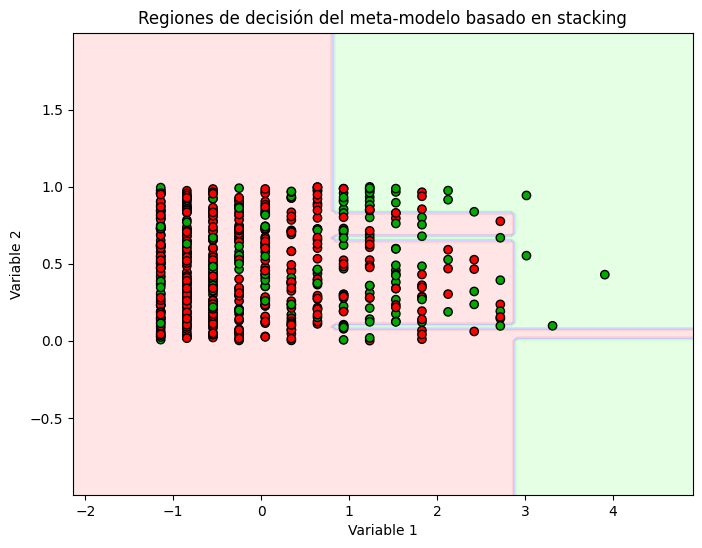

In [68]:
from matplotlib.colors import ListedColormap

# Límites de la gráfica
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

# Malla de puntos
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predicciones
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(["#FFAAAA", "#AAAAFF", "#AAFFAA"])
cmap_bold = ListedColormap(["#FF0000", "#0000FF", "#00AA00"])

# Regiones de decisión
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)

# Puntos de datos originales
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolor="k")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Regiones de decisión del meta-modelo basado en stacking")
plt.show()